# 1. Kiểm tra data leakage

In [45]:
import hashlib
from pathlib import Path

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def compute_md5(file_path):
    """Tính MD5 của một ảnh"""
    with open(file_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


def get_image_hashes(folder):
    """
    Trả về dict:
        md5 -> đường dẫn ảnh
    """
    hashes = {}

    for img in Path(folder).rglob("*"):
        if img.suffix.lower() not in IMG_EXT:
            continue

        md5 = compute_md5(img)
        hashes[md5] = img

    return hashes


# ==========================
# Đường dẫn dataset
# ==========================

train_dir = "/Users/mac/Detect_Drill_Bit/original-data/train"
valid_dir = "/Users/mac/Detect_Drill_Bit/original-data/valid"
test_dir = "/Users/mac/Detect_Drill_Bit/original-data/test"

# ==========================
# Tính hash
# ==========================

train_hash = get_image_hashes(train_dir)
valid_hash = get_image_hashes(valid_dir)
test_hash = get_image_hashes(test_dir)

# ==========================
# Kiểm tra leakage
# ==========================

train_valid = set(train_hash) & set(valid_hash)
train_test = set(train_hash) & set(test_hash)
valid_test = set(valid_hash) & set(test_hash)

print("=" * 60)
print("DATA LEAKAGE REPORT")
print("=" * 60)

print(f"Train ↔ Valid : {len(train_valid)}")
print(f"Train ↔ Test  : {len(train_test)}")
print(f"Valid ↔ Test  : {len(valid_test)}")

# ==========================
# Hiển thị chi tiết
# ==========================

if train_valid:
    print("\nTrain ↔ Valid")
    for h in train_valid:
        print(f"Train : {train_hash[h]}")
        print(f"Valid : {valid_hash[h]}")
        print("-" * 60)

if train_test:
    print("\nTrain ↔ Test")
    for h in train_test:
        print(f"Train : {train_hash[h]}")
        print(f"Test  : {test_hash[h]}")
        print("-" * 60)

if valid_test:
    print("\nValid ↔ Test")
    for h in valid_test:
        print(f"Valid : {valid_hash[h]}")
        print(f"Test  : {test_hash[h]}")
        print("-" * 60)

if not (train_valid or train_test or valid_test):
    print("\n✅ Không phát hiện data leakage.")

DATA LEAKAGE REPORT
Train ↔ Valid : 38
Train ↔ Test  : 0
Valid ↔ Test  : 0

Train ↔ Valid
Train : /Users/mac/Detect_Drill_Bit/original-data/train/Bright_Field/top/S8_dau_Image__2025-09-03__14-34-37_bright_1_crop_9_jpg.rf.1cf02a02b7b43cca8daedcb43d265655.jpg
Valid : /Users/mac/Detect_Drill_Bit/original-data/valid/Bright_Field/top/S8_dau_Image__2025-09-03__14-34-37_bright_1_crop_9_jpg.rf.1cf02a02b7b43cca8daedcb43d265655.jpg
------------------------------------------------------------
Train : /Users/mac/Detect_Drill_Bit/original-data/train/Bright_Field/top/S193_Image__2025-05-29__14-43-46_bright_1_crop_9_jpg.rf.f1014b5a06902ff14271661b407bf430.jpg
Valid : /Users/mac/Detect_Drill_Bit/original-data/valid/Bright_Field/top/S193_Image__2025-05-29__14-43-46_bright_1_crop_9_jpg.rf.f1014b5a06902ff14271661b407bf430.jpg
------------------------------------------------------------
Train : /Users/mac/Detect_Drill_Bit/original-data/train/Dark_Field/top/S62_Image__2025-09-08__09-56-20_dark_1_crop_9_jpg

# 2.Kiểm tra phân bố class

### 1. Train

In [10]:
import json
from collections import Counter
import pandas as pd

json_path = "/Users/mac/Detect_Drill_Bit/original-data/train/_annotations.coco.json"

with open(json_path, "r") as f:
    coco = json.load(f)

# id -> tên class
id2name = {c["id"]: c["name"] for c in coco["categories"]}

counter = Counter()

for ann in coco["annotations"]:
    counter[id2name[ann["category_id"]]] += 1

df = pd.DataFrame(
    counter.items(),
    columns=["Class", "Objects"]
).sort_values("Objects", ascending=False)

print(df)

         Class  Objects
0    Scratched     1367
2  Severe_Rust     1205
4      Chipped     1139
1     Tip_Wear      934
3       Broken      802


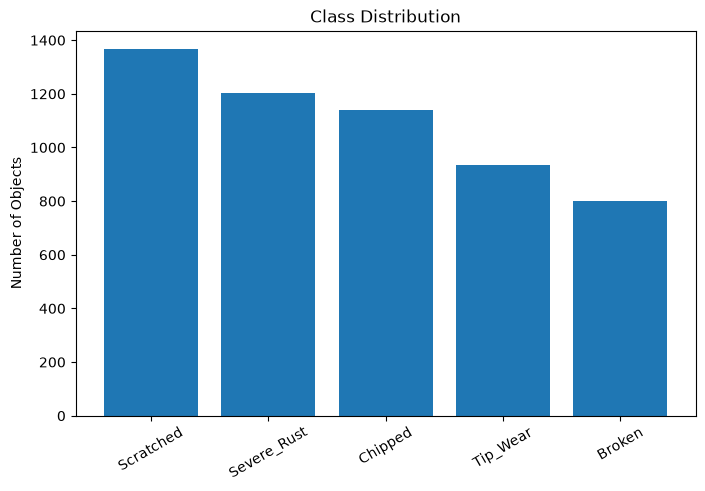

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["Class"], df["Objects"])
plt.ylabel("Number of Objects")
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.show()

### 2. Val

In [12]:
import json
from collections import Counter
import pandas as pd

json_path = "/Users/mac/Detect_Drill_Bit/original-data/valid/_annotations.coco.json"

with open(json_path, "r") as f:
    coco = json.load(f)

# id -> tên class
id2name = {c["id"]: c["name"] for c in coco["categories"]}

counter = Counter()

for ann in coco["annotations"]:
    counter[id2name[ann["category_id"]]] += 1

df = pd.DataFrame(
    counter.items(),
    columns=["Class", "Objects"]
).sort_values("Objects", ascending=False)

print(df)

         Class  Objects
3     Tip_Wear      246
0    Scratched      217
4  Severe_Rust      210
2       Broken      190
1      Chipped      164


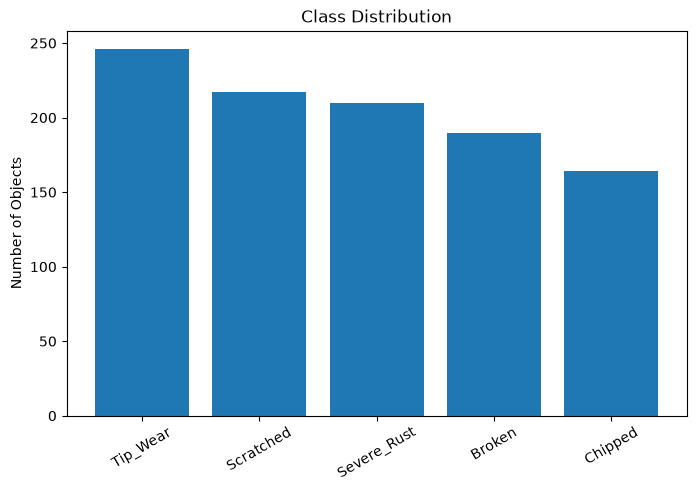

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["Class"], df["Objects"])
plt.ylabel("Number of Objects")
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.show()

### 3. Test

In [14]:
import json
from collections import Counter
import pandas as pd

json_path = "/Users/mac/Detect_Drill_Bit/original-data/test/Dark_Field/_annotations.coco.json"

with open(json_path, "r") as f:
    coco = json.load(f)

# id -> tên class
id2name = {c["id"]: c["name"] for c in coco["categories"]}

counter = Counter()

for ann in coco["annotations"]:
    counter[id2name[ann["category_id"]]] += 1

df = pd.DataFrame(
    counter.items(),
    columns=["Class", "Objects"]
).sort_values("Objects", ascending=False)

print(df)

         Class  Objects
3  Severe_Rust      235
0    Scratched      203
1       Broken      128
2      Chipped      105
4     Tip_Wear       93


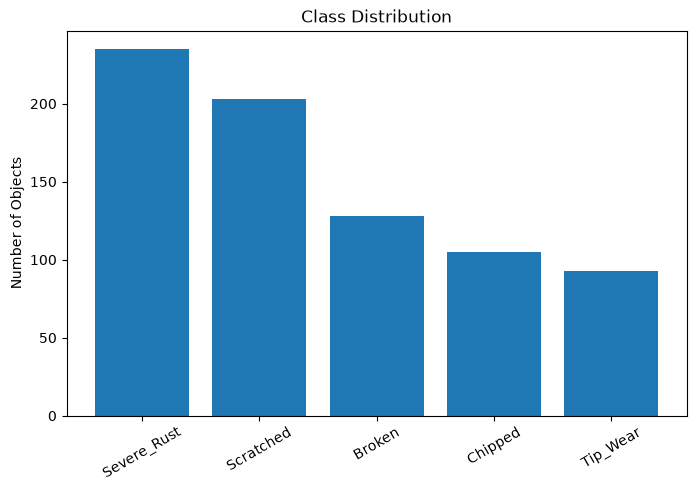

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["Class"], df["Objects"])
plt.ylabel("Number of Objects")
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.show()

In [16]:
import json
from collections import Counter
import pandas as pd

json_path = "/Users/mac/Detect_Drill_Bit/original-data/test/Bright_Field/_annotations.coco.json"

with open(json_path, "r") as f:
    coco = json.load(f)

# id -> tên class
id2name = {c["id"]: c["name"] for c in coco["categories"]}

counter = Counter()

for ann in coco["annotations"]:
    counter[id2name[ann["category_id"]]] += 1

df = pd.DataFrame(
    counter.items(),
    columns=["Class", "Objects"]
).sort_values("Objects", ascending=False)

print(df)

         Class  Objects
3  Severe_Rust      231
0    Scratched      200
4       Broken      127
2      Chipped      108
1     Tip_Wear       92


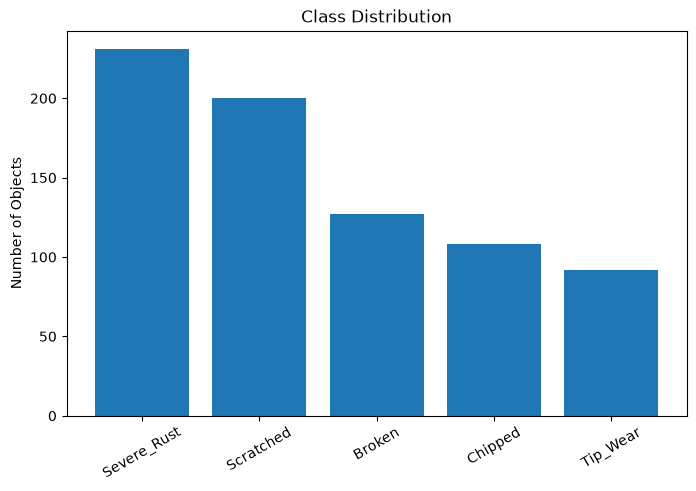

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["Class"], df["Objects"])
plt.ylabel("Number of Objects")
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.show()

# 3. Kiểm tra Annotation

### 1. Train

In [22]:
import json

json_path = "/Users/mac/Detect_Drill_Bit/original-data/train/_annotations.coco.json"

with open(json_path) as f:
    coco = json.load(f)

img_info = {img["id"]: img for img in coco["images"]}

errors = []

for ann in coco["annotations"]:
    img = img_info[ann["image_id"]]

    x, y, w, h = ann["bbox"]

    if (
        x < 0 or
        y < 0 or
        w <= 0 or
        h <= 0 or
        x + w > img["width"] or
        y + h > img["height"]
    ):
        errors.append(ann["id"])

print("BBox lỗi:", len(errors))

BBox lỗi: 0


In [23]:
# kiểm tra xem có annotation quá nhỏ không?
small = []

for ann in coco["annotations"]:
    _, _, w, h = ann["bbox"]

    if w < 5 or h < 5:
        small.append(ann["id"])

print("BBox nhỏ:", len(small))

BBox nhỏ: 0


In [24]:
# kiểm tra xem có duplicate không
from collections import defaultdict

dup = defaultdict(int)

for ann in coco["annotations"]:
    key = (
        ann["image_id"],
        ann["category_id"],
        tuple(map(int, ann["bbox"]))
    )
    dup[key] += 1

duplicates = [k for k, v in dup.items() if v > 1]

print("Duplicate:", len(duplicates))

Duplicate: 0


### 2. Val

In [25]:
import json

json_path = "/Users/mac/Detect_Drill_Bit/original-data/valid/_annotations.coco.json"

with open(json_path) as f:
    coco = json.load(f)

img_info = {img["id"]: img for img in coco["images"]}

errors = []

for ann in coco["annotations"]:
    img = img_info[ann["image_id"]]

    x, y, w, h = ann["bbox"]

    if (
        x < 0 or
        y < 0 or
        w <= 0 or
        h <= 0 or
        x + w > img["width"] or
        y + h > img["height"]
    ):
        errors.append(ann["id"])

print("BBox lỗi:", len(errors))

BBox lỗi: 0


In [26]:
# kiểm tra xem có annotation quá nhỏ không?
small = []

for ann in coco["annotations"]:
    _, _, w, h = ann["bbox"]

    if w < 5 or h < 5:
        small.append(ann["id"])

print("BBox nhỏ:", len(small))

BBox nhỏ: 0


In [27]:
# kiểm tra xem có duplicate không
from collections import defaultdict

dup = defaultdict(int)

for ann in coco["annotations"]:
    key = (
        ann["image_id"],
        ann["category_id"],
        tuple(map(int, ann["bbox"]))
    )
    dup[key] += 1

duplicates = [k for k, v in dup.items() if v > 1]

print("Duplicate:", len(duplicates))

Duplicate: 0


### 3. Test

In [28]:
import json

json_path = "/Users/mac/Detect_Drill_Bit/original-data/test/Dark_Field/_annotations.coco.json"

with open(json_path) as f:
    coco = json.load(f)

img_info = {img["id"]: img for img in coco["images"]}

errors = []

for ann in coco["annotations"]:
    img = img_info[ann["image_id"]]

    x, y, w, h = ann["bbox"]

    if (
        x < 0 or
        y < 0 or
        w <= 0 or
        h <= 0 or
        x + w > img["width"] or
        y + h > img["height"]
    ):
        errors.append(ann["id"])

print("BBox lỗi:", len(errors))

BBox lỗi: 0


In [29]:
# kiểm tra xem có annotation quá nhỏ không?
small = []

for ann in coco["annotations"]:
    _, _, w, h = ann["bbox"]

    if w < 5 or h < 5:
        small.append(ann["id"])

print("BBox nhỏ:", len(small))

BBox nhỏ: 0


In [30]:
# kiểm tra xem có duplicate không
from collections import defaultdict

dup = defaultdict(int)

for ann in coco["annotations"]:
    key = (
        ann["image_id"],
        ann["category_id"],
        tuple(map(int, ann["bbox"]))
    )
    dup[key] += 1

duplicates = [k for k, v in dup.items() if v > 1]

print("Duplicate:", len(duplicates))

Duplicate: 0


In [31]:
import json

json_path = "/Users/mac/Detect_Drill_Bit/original-data/test/Bright_Field/_annotations.coco.json"

with open(json_path) as f:
    coco = json.load(f)

img_info = {img["id"]: img for img in coco["images"]}

errors = []

for ann in coco["annotations"]:
    img = img_info[ann["image_id"]]

    x, y, w, h = ann["bbox"]

    if (
        x < 0 or
        y < 0 or
        w <= 0 or
        h <= 0 or
        x + w > img["width"] or
        y + h > img["height"]
    ):
        errors.append(ann["id"])

print("BBox lỗi:", len(errors))

BBox lỗi: 0


In [32]:
# kiểm tra xem có annotation quá nhỏ không?
small = []

for ann in coco["annotations"]:
    _, _, w, h = ann["bbox"]

    if w < 5 or h < 5:
        small.append(ann["id"])

print("BBox nhỏ:", len(small))

BBox nhỏ: 0


In [33]:
# kiểm tra xem có duplicate không
from collections import defaultdict

dup = defaultdict(int)

for ann in coco["annotations"]:
    key = (
        ann["image_id"],
        ann["category_id"],
        tuple(map(int, ann["bbox"]))
    )
    dup[key] += 1

duplicates = [k for k, v in dup.items() if v > 1]

print("Duplicate:", len(duplicates))

Duplicate: 0


# 4. Kiểm tra object size

### 1. Train

In [34]:
import json
import pandas as pd

json_path = "/Users/mac/Detect_Drill_Bit/original-data/train/_annotations.coco.json"

with open(json_path, "r") as f:
    coco = json.load(f)

img_info = {img["id"]: img for img in coco["images"]}
id2name = {c["id"]: c["name"] for c in coco["categories"]}

rows = []

for ann in coco["annotations"]:
    img = img_info[ann["image_id"]]
    x, y, w, h = ann["bbox"]

    rows.append({
        "class": id2name[ann["category_id"]],
        "width": w,
        "height": h,
        "area": w * h,
        "image_area": img["width"] * img["height"],
        "ratio": (w * h) / (img["width"] * img["height"])
    })

df = pd.DataFrame(rows)

print(df.describe())

             width       height          area  image_area        ratio
count  5447.000000  5447.000000   5447.000000      5447.0  5447.000000
mean     62.582522   112.560676   7818.972095    200704.0     0.038958
std      37.577069    69.156674   8254.286385         0.0     0.041127
min      10.000000    18.000000    280.000000    200704.0     0.001395
25%      35.000000    62.000000   2640.000000    200704.0     0.013154
50%      50.000000    94.000000   4788.000000    200704.0     0.023856
75%      77.000000   143.000000   9869.500000    200704.0     0.049174
max     159.000000   441.000000  62926.000000    200704.0     0.313526


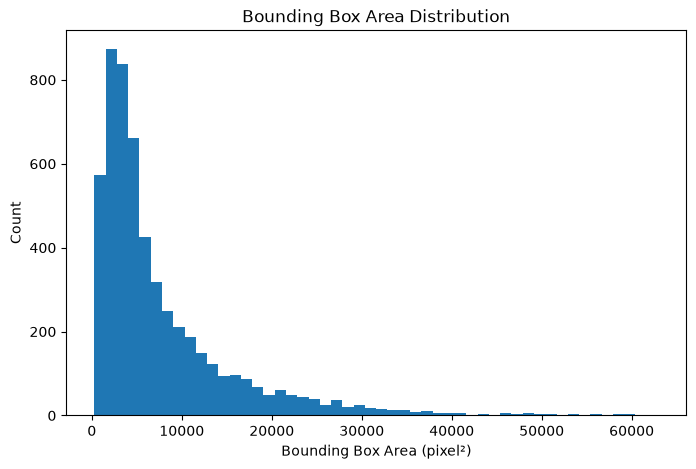

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["area"], bins=50)
plt.xlabel("Bounding Box Area (pixel²)")
plt.ylabel("Count")
plt.title("Bounding Box Area Distribution")
plt.show()

In [36]:
print(df["ratio"].describe())

count    5447.000000
mean        0.038958
std         0.041127
min         0.001395
25%         0.013154
50%         0.023856
75%         0.049174
max         0.313526
Name: ratio, dtype: float64


In [37]:
result = (
    df.groupby("class")["ratio"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("mean")
)

print(result)

             count      mean    median       min       max
class                                                     
Chipped       1139  0.014661  0.009576  0.001395  0.094169
Tip_Wear       934  0.017667  0.016749  0.002272  0.052077
Scratched     1367  0.031956  0.024235  0.003049  0.219203
Severe_Rust   1205  0.065163  0.044324  0.002242  0.313526
Broken         802  0.070819  0.063960  0.015072  0.190086


In [38]:
def size_type(r):
    if r < 0.001:
        return "Tiny"
    elif r < 0.01:
        return "Small"
    else:
        return "Large"

df["size"] = df["ratio"].apply(size_type)

print(df["size"].value_counts())

size
Large    4528
Small     919
Name: count, dtype: int64


# 5. Kiểm tra duplicate

### 1. Train

In [39]:
import hashlib
from pathlib import Path
from collections import defaultdict

def get_duplicate_images(root_dir):
    hashes = defaultdict(list)

    for img in Path(root_dir).rglob("*"):
        if img.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp"]:
            continue

        md5 = hashlib.md5(img.read_bytes()).hexdigest()
        hashes[md5].append(str(img))

    duplicates = {h: paths for h, paths in hashes.items() if len(paths) > 1}

    print(f"📌 Số nhóm ảnh trùng: {len(duplicates)}")

    for paths in duplicates.values():
        print("-" * 80)
        for p in paths:
            print(p)

    return hashes

In [40]:
train_hash = get_duplicate_images("/Users/mac/Detect_Drill_Bit/original-data/train")

📌 Số nhóm ảnh trùng: 0


### train-val-test

In [41]:
import hashlib
from pathlib import Path

def get_hashes(root_dir):
    hashes = {}

    for img in Path(root_dir).rglob("*"):
        if img.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp"]:
            continue

        md5 = hashlib.md5(img.read_bytes()).hexdigest()
        hashes[md5] = str(img)

    return hashes

train = get_hashes("/Users/mac/Detect_Drill_Bit/original-data/train")
valid = get_hashes("/Users/mac/Detect_Drill_Bit/original-data/valid")
test  = get_hashes("/Users/mac/Detect_Drill_Bit/original-data/test")

tv = set(train) & set(valid)
tt = set(train) & set(test)
vt = set(valid) & set(test)

print("Train ↔ Valid :", len(tv))
print("Train ↔ Test  :", len(tt))
print("Valid ↔ Test  :", len(vt))

Train ↔ Valid : 38
Train ↔ Test  : 0
Valid ↔ Test  : 0


In [42]:
for h in tv:
    print("Train :", train[h])
    print("Valid :", valid[h])
    print()

Train : /Users/mac/Detect_Drill_Bit/original-data/train/Bright_Field/top/S8_dau_Image__2025-09-03__14-34-37_bright_1_crop_9_jpg.rf.1cf02a02b7b43cca8daedcb43d265655.jpg
Valid : /Users/mac/Detect_Drill_Bit/original-data/valid/Bright_Field/top/S8_dau_Image__2025-09-03__14-34-37_bright_1_crop_9_jpg.rf.1cf02a02b7b43cca8daedcb43d265655.jpg

Train : /Users/mac/Detect_Drill_Bit/original-data/train/Bright_Field/top/S193_Image__2025-05-29__14-43-46_bright_1_crop_9_jpg.rf.f1014b5a06902ff14271661b407bf430.jpg
Valid : /Users/mac/Detect_Drill_Bit/original-data/valid/Bright_Field/top/S193_Image__2025-05-29__14-43-46_bright_1_crop_9_jpg.rf.f1014b5a06902ff14271661b407bf430.jpg

Train : /Users/mac/Detect_Drill_Bit/original-data/train/Dark_Field/top/S62_Image__2025-09-08__09-56-20_dark_1_crop_9_jpg.rf.1eb2a9e45bb242df400eae797da40910.jpg
Valid : /Users/mac/Detect_Drill_Bit/original-data/valid/Dark_Field/top/S62_Image__2025-09-08__09-56-20_dark_1_crop_9_jpg.rf.1eb2a9e45bb242df400eae797da40910.jpg

Train :